#### IMPORTANT: Please download the following data and save under ./data to be able to run the notebook:

- QTP_RTS_mass_wasting_2011_2020.gpkg from https://doi.org/10.3929/ethz-b-000735734 
- QTP_RTS_2020.shp, QTP_RTS_2020.shx, QTP_RTS_2020.cpg, QTP_RTS_2020.dbf, QTP_RTS_2020.prj from https://doi.org/10.5281/zenodo.10928346

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import rasterio
from scipy.stats import norm, linregress

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import helpers.allometric_scaling as allometric_scaling

font_path = font_manager.findfont('Liberation Sans') 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans']

In [38]:
# General settings
crs = 6933
light_blue = '#9cbdff'
blue = '#0055ff'
blues = sns.color_palette("Blues_r", 5)
greys = sns.color_palette("Greys_r", 5)
light_turquoise = '#71bfb4'
turquoise = '#14665b'

In [53]:
# Read data for entire QTP
all_labels = gpd.read_file("./data/QTP_RTS_mass_wasting_2011_2020_v0_1.gpkg", crs=crs)
cluster_labels = gpd.read_file("./data/QTP_RTS_2020.shp", crs=crs)

cluster_dict = {
    "Individual": [0],
    "West": [1, 2],
    "West-Central": [3, 4, 5, 6, 7, 8, 9, 10],
    "Central": [11, 12, 13, 14, 15, 16, 17, 18],
    "East": [19, 20],
    "North-East": [21, 22],
}
median_order = ["West", "West-Central", "Central", "East", "North-East"]

# Filter and prepare data for analysis and plotting
all_labels.dropna(subset=['area', 'area_neg', 'area_exact', 'dv_loss'], inplace=True)
all_labels = all_labels[(all_labels['area'] > 0) & (all_labels['area_neg'] > 0) & (all_labels['area_exact'] > 0)]
all_labels = all_labels.merge(cluster_labels[['id', 'Cluster']], on='id', how='left')
all_labels.rename(columns={'Cluster': 'cluster'}, inplace=True)
all_labels['cluster_name'] = all_labels['cluster'].map({v: k for k, vals in cluster_dict.items() for v in vals})
all_labels["gi_data_column"] = all_labels[['data_gi5_10m', 'data_gi3_5m', 'data_gi2_3m']].sum(axis=1)
all_labels["gi_data_column_upper"] = all_labels[['data_gi5_10m_upper', 'data_gi3_5m_upper', 'data_gi2_3m_upper']].sum(axis=1)
all_labels["gi_data_column_lower"] = all_labels[['data_gi5_10m_lower', 'data_gi3_5m_lower', 'data_gi2_3m_lower']].sum(axis=1)
all_labels['wang_soc_gi_independent'] = all_labels[['wang_soc0_1m', 'wang_soc1_2m']].sum(axis=1)
all_labels['wang_soc_gi_dependent'] = all_labels[['wang_soc2_3m','wang_exp_soc_under3m']].sum(axis=1)
all_labels['wang_soc_column_content'] = all_labels[['content_wang_soc0_1m', 'content_wang_soc1_2m', 'content_wang_soc2_3m']].sum(axis=1)
all_labels['gi_data_perc_mean'] = all_labels[['gi_data_perc_gi5_10m', 'gi_data_perc_gi3_5m', 'gi_data_perc_gi2_3m']].mean(axis=1)
all_labels.loc[:, 'data_gi_column'] = all_labels[['data_gi2_3m', 'data_gi3_5m', 'data_gi5_10m']].sum(axis=1)

print(f"Number of RTSs: {len(all_labels)}")
print(f"Number of removed RTSs due to SAR quality issues (coherence < 0.3, layover/shadow) or missing data: {round(len(all_labels[all_labels['quality'] == 0]) / len(all_labels) * 100, 1)}, #: {len(all_labels[all_labels['quality'] == 0])}")

Number of RTSs: 3613
Number of removed RTSs due to SAR quality issues (coherence < 0.3, layover/shadow) or missing data: 2.0, #: 71


Analysis: Statistics for QTP mass wasting including subregions

In [49]:
all_labels['dv_loss_yearly'] = all_labels['dv_loss'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['dv_loss_yearly_upper'] = all_labels['dv_loss_upper'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['dv_loss_yearly_lower'] = all_labels['dv_loss_lower'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['soc_yearly'] = all_labels['gi_data_wang_exp_soc_column'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['soc_yearly_upper'] = all_labels['gi_data_wang_exp_soc_column_upper'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['soc_yearly_lower'] = all_labels['gi_data_wang_exp_soc_column_lower'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['gi_yearly'] = all_labels['data_gi_column'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['gi_yearly_upper'] = all_labels['gi_data_column_upper'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)
all_labels['gi_yearly_lower'] = all_labels['gi_data_column_lower'] / (all_labels['years'].apply(lambda x: max(map(int, x.split(',')))) - 2011)

rts_level = all_labels.copy()
print(f"Number of RTSs: {len(all_labels)}")
print(f"Average area of RTSs: {all_labels['area'].median():.2f} m²  with std {all_labels['area'].std():.2f}")
print(f"Average active erosion area of RTSs: {all_labels['area_neg'].median():.2f} m² with std {all_labels['area_neg'].std():.2f}")
print(f"Average percentage of active erosion area vs. total scar zone area: {all_labels['area_neg'].median() / all_labels['area'].median() * 100:.2f}% with std {all_labels['area_neg'].std() / all_labels['area'].std() * 100:.2f}%")
print(f"Average elevation loss of RTSs: {all_labels['dh_loss'].median():.2f} m with error {all_labels['sigma_dh_loss'].median():.2f} m (relative error: {all_labels['sigma_dv_loss'].median() / all_labels['dv_loss'].median() * 100:.2f}%)")
print(f"Average volume loss of RTSs: {all_labels['dv_loss'].median():.2f} m³ with error {all_labels['sigma_dv_loss'].median():.2f} m³ (relative error: {all_labels['sigma_dv_loss'].median() / all_labels['dv_loss'].median() * 100:.2f}%)")

print(f"Median headwall height: {(all_labels['dv_loss'] / all_labels['area_neg']).median():.2f} m, mean headwall height: {(all_labels['dv_loss'] / all_labels['area_neg']).mean():.2f} m")
print(f"5%ile of headwall height: {(all_labels['dv_loss'] / all_labels['area_neg']).quantile(0.05):.2f} m, 95% percentile of headwall height: {(all_labels['dv_loss'] / all_labels['area_neg']).quantile(0.95):.2f} m")

print(f"Volume loss on QTP: {all_labels['dv_loss'].sum():.2f} m³ (upper: {all_labels['dv_loss_upper'].sum():.2f} m³, lower: {all_labels['dv_loss_lower'].sum():.2f} m³)")
print(f"Median and mean ground ice content: {all_labels['gi_data_perc_mean'].median():.2f}%, {all_labels['gi_data_perc_mean'].mean():.2f}%")
print(f"Ground ice loss on QTP: {all_labels['data_gi_column'].sum():.2f} m³ (upper: {all_labels['gi_data_column_upper'].sum():.2f} m³, lower: {all_labels['gi_data_column_lower'].sum():.2f} m³)")
print(f"Percentage of material loss due to ground ice: {all_labels['data_gi_column'].sum() / all_labels['dv_loss'].sum() * 100:.2f}%")
print(f"Percentage of material loss due to ground ice (upper): {all_labels['gi_data_column_upper'].sum() / all_labels['dv_loss_upper'].sum() * 100:.2f}%")
print(f"Percentage of material loss due to ground ice (lower): {all_labels['gi_data_column_lower'].sum() / all_labels['dv_loss_lower'].sum() * 100:.2f}%")
print(f"SOC mobilisation on QTP: {all_labels['gi_data_wang_exp_soc_column'].sum():.2f} kg C (upper: {all_labels['gi_data_wang_exp_soc_column_upper'].sum():.2f} kg C, lower: {all_labels['gi_data_wang_exp_soc_column_lower'].sum():.2f} kg C)")
print(f"SOC fluxes on QTP: {all_labels['soc_yearly'].sum():.2f} kg C/yr (upper: {all_labels['soc_yearly_upper'].sum():.2f} kg C/yr, lower: {all_labels['soc_yearly_lower'].sum():.2f} kg C/yr)")
print(f"SOC fluxes per unit area on QTP: {all_labels['soc_yearly'].sum() / 68200:.2f} kg C/yr/km² (upper: {all_labels['soc_yearly_upper'].sum() / 68200:.2f} kg C/yr/km², lower: {all_labels['soc_yearly_lower'].sum() / 68200:.2f} kg C/yr/km²)")
print(f"Volume loss per year: {all_labels['dv_loss_yearly'].sum():.2f} m³/yr (upper: {all_labels['dv_loss_yearly_upper'].sum():.2f} m³/yr, lower: {all_labels['dv_loss_yearly_lower'].sum():.2f} m³/yr)")
print("-------------------Per RTS-------------------")
print(f"Volume loss per RTS: {rts_level['dv_loss'].sum() / len(rts_level):.2f} m³ (upper: {rts_level['dv_loss_upper'].sum() / len(rts_level):.2f} m³, lower: {rts_level['dv_loss_lower'].sum() / len(rts_level):.2f} m³)")
print(f"Ground ice per RTS: {rts_level['data_gi_column'].sum() / len(rts_level):.2f} m³ (upper: {rts_level['gi_data_column_upper'].sum() / len(rts_level):.2f} m³, lower: {rts_level['gi_data_column_lower'].sum() / len(rts_level):.2f} m³)")
print(f"SOC mobilisation per RTS: {rts_level['gi_data_wang_exp_soc_column'].sum() / len(rts_level):.2f}kg C (upper: {rts_level['gi_data_wang_exp_soc_column_upper'].sum() / len(rts_level):.2f} kg C, lower: {rts_level['gi_data_wang_exp_soc_column_lower'].sum() / len(rts_level):.2f} kg C)")
print(f"Volume loss per RTS per year: {rts_level['dv_loss_yearly'].sum() / len(rts_level):.2f} m³ (upper: {rts_level['dv_loss_yearly_upper'].sum() / len(rts_level):.2f} m³, lower: {rts_level['dv_loss_yearly_lower'].sum() / len(rts_level):.2f} m³)")
print(f"Ground ice per RTS per year: {rts_level['gi_yearly'].sum() / len(rts_level):.2f} m³ (upper: {rts_level['gi_yearly_upper'].sum() / len(rts_level):.2f} m³, lower: {rts_level['gi_yearly_lower'].sum() / len(rts_level):.2f} m³)")
print(f"SOC fluxes per RTS per year: {rts_level['soc_yearly'].sum() / len(rts_level):.2f} kg C (upper: {rts_level['soc_yearly_upper'].sum() / len(rts_level):.2f} kg C, lower: {rts_level['soc_yearly_lower'].sum() / len(rts_level):.2f} kg C)")
for cluster in median_order:
    count = rts_level[rts_level['cluster_name'] == cluster]['gi_data_perc_mean'].count()
    print(f"\n-------------------{cluster}-------------------\n")
    print(f"Number of RTSs: {count}")
    print(f"Percentage of RTSs: {count / len(rts_level) * 100:.2f}%")
    print(f"Average area of RTSs: {rts_level[rts_level['cluster_name'] == cluster]['area'].median():.2f} m²")
    print(f"Average active erosion area of RTSs: {rts_level[rts_level['cluster_name'] == cluster]['area_neg'].median():.2f} m²")
    print(f"Perc. of active erosion area vs. total scar zone area: {rts_level[rts_level['cluster_name'] == cluster]['area_neg'].mean() / rts_level[rts_level['cluster_name'] == cluster]['area'].mean() * 100:.2f}%")
    print(f"Total volume loss: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss'].sum():.2f} m³ (upper: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss_upper'].sum():.2f} m³, lower: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss_lower'].sum():.2f} m³)")
    print(f"Percentage of volume loss compared to all RTSs: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss'].sum() / rts_level['dv_loss'].sum() * 100:.2f}%")
    print(f"Total ground ice loss: {rts_level[rts_level['cluster_name'] == cluster]['data_gi_column'].sum():.2f} m³ (upper: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_column_upper'].sum():.2f} m³, lower: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_column_lower'].sum():.2f} m³)")
    print(f"Percentage of ground ice loss compared to all RTSs: {rts_level[rts_level['cluster_name'] == cluster]['data_gi_column'].sum() / rts_level['data_gi_column'].sum() * 100:.2f}%")
    print(f"Total SOC mobilisation: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_wang_exp_soc_column'].sum():.2f} kg C (upper: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_wang_exp_soc_column_upper'].sum():.2f} kg C, lower: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_wang_exp_soc_column_lower'].sum():.2f} kg C)")
    print(f"Percentage of SOC mobilisation compared to all RTSs: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_wang_exp_soc_column'].sum() / rts_level['gi_data_wang_exp_soc_column'].sum() * 100:.2f}%")
    print(f"Total SOC fluxes: {rts_level[rts_level['cluster_name'] == cluster]['soc_yearly'].sum():.2f} kg C/yr (upper: {rts_level[rts_level['cluster_name'] == cluster]['soc_yearly_upper'].sum():.2f} kg C/yr, lower: {rts_level[rts_level['cluster_name'] == cluster]['soc_yearly_lower'].sum():.2f} kg C/yr)")
    print(f"Volume loss per RTS: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss'].median():.2f} m³ (upper: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss_upper'].median():.2f} m³, lower: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss_lower'].median():.2f} m³)")
    
    print(f"Median headwall height: {(rts_level[rts_level['cluster_name'] == cluster]['dv_loss'] / rts_level[rts_level['cluster_name'] == cluster]['area_neg']).median():.2f} m, mean headwall height: {(rts_level[rts_level['cluster_name'] == cluster]['dv_loss'] / all_labels['area_neg']).mean():.2f} m")
    print(f"5%ile of headwall height: {(rts_level[rts_level['cluster_name'] == cluster]['dv_loss'] / rts_level[rts_level['cluster_name'] == cluster]['area_neg']).quantile(0.05):.2f} m, 95% percentile of headwall height: {(rts_level[rts_level['cluster_name'] == cluster]['dv_loss'] / rts_level[rts_level['cluster_name'] == cluster]['area_neg']).quantile(0.95):.2f} m")
    
    print(f"Median and mean ground ice content: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_perc_mean'].median():.2f}%, {rts_level[rts_level['cluster_name'] == cluster]['gi_data_perc_mean'].mean():.2f}%")
    print(f"Ground ice per RTS: {rts_level[rts_level['cluster_name'] == cluster]['data_gi_column'].sum() / count:.2f} m³ (upper: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_column_upper'].sum() / count:.2f} m³, lower: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_column_lower'].sum() / count:.2f} m³)")
    print(f"SOC mobilisation per RTS: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_wang_exp_soc_column'].sum() / count:.2f} kg C (upper: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_wang_exp_soc_column_upper'].sum() / count:.2f} kg C, lower: {rts_level[rts_level['cluster_name'] == cluster]['gi_data_wang_exp_soc_column_lower'].sum() / count:.2f} kg C)")
    print(f"Volume loss per RTS per year: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss_yearly'].sum() / count:.2f} m³ (upper: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss_yearly_upper'].sum() / count:.2f} m³, lower: {rts_level[rts_level['cluster_name'] == cluster]['dv_loss_yearly_lower'].sum() / count:.2f} m³)")
    print(f"Ground ice per RTS per year: {rts_level[rts_level['cluster_name'] == cluster]['gi_yearly'].sum() / count:.2f} m³ (upper: {rts_level[rts_level['cluster_name'] == cluster]['gi_yearly_upper'].sum() / count:.2f} m³, lower: {rts_level[rts_level['cluster_name'] == cluster]['gi_yearly_lower'].sum() / count:.2f} m³)")
    print(f"SOC fluxes per RTS per year: {rts_level[rts_level['cluster_name'] == cluster]['soc_yearly'].sum() / count:.2f} kg C (upper: {rts_level[rts_level['cluster_name'] == cluster]['soc_yearly_upper'].sum() / count:.2f} kg C, lower: {rts_level[rts_level['cluster_name'] == cluster]['soc_yearly_lower'].sum() / count:.2f} kg C)")

Number of RTSs: 3613
Average area of RTSs: 8000.00 m²  with std 17005.59
Average active erosion area of RTSs: 5200.00 m² with std 10589.90
Average percentage of active erosion area vs. total scar zone area: 65.00% with std 62.27%
Average elevation loss of RTSs: 63.30 m with error 22.61 m (relative error: 35.71%)
Average volume loss of RTSs: 6330.22 m³ with error 2260.57 m³ (relative error: 35.71%)
Median headwall height: 1.21 m, mean headwall height: 1.41 m
5%ile of headwall height: 0.51 m, 95% percentile of headwall height: 2.54 m
Volume loss on QTP: 50235947.69 m³ (upper: 253485786.22 m³, lower: 7463627.24 m³)
Median and mean ground ice content: 32.21%, 30.77%
Ground ice loss on QTP: 3580981.53 m³ (upper: 28199092.89 m³, lower: 279830.17 m³)
Percentage of material loss due to ground ice: 7.13%
Percentage of material loss due to ground ice (upper): 11.12%
Percentage of material loss due to ground ice (lower): 3.75%
SOC mobilisation on QTP: 39919.98 kg C (upper: 830651271.34 kg C, lowe

Analysis for validation on test sites

In [28]:
# Read data for validation in test sites
years = [2018, 2019, 2020]
locations = ["central", "highway", "south", "west", "east"] 
location_mapping = {
    "central": "Western Central",
    "west": "West",
    "east": "Qilian Mountain",
    "south": "South",
    "highway": "Beiluhe River Basin"
}

dems = []
opticals = []
stats = pd.DataFrame()
ids = pd.DataFrame()
for location in locations:
    dem = gpd.read_file(f"./validation/polygons_dem_plain_{location}_2010_2020.geojson", crs=crs)
    dems.append(dem)
    for year in years:
        optical = gpd.read_file(f"./validation/polygons_optical_plain_{location}_{year}_{year}.geojson", crs=crs)
        opticals.append(optical)
        dem_ids = set(dem['id'].astype(int))
        optical_ids = set(optical['id'].astype(int))
        common_count = len(dem_ids.intersection(optical_ids))
        stats = pd.concat([stats, pd.DataFrame([{
            'location': location,
            'year': year,
            'total': len(dem_ids.union(optical_ids)),
            'x': len(dem_ids) - common_count,
            'y': len(optical_ids) - common_count,
            'F1': common_count / (len(dem_ids) + len(optical_ids) - common_count)
        }])], ignore_index=True)
        ids = pd.concat([ids, pd.DataFrame([{
            'year': year,
            'total_ids': len(dem_ids.union(optical_ids)),
            'common_ids': dem_ids.intersection(optical_ids),
            'missing_optical': dem_ids - dem_ids.intersection(optical_ids),
            'missing_dem': optical_ids - optical_ids.intersection(dem_ids)
        }])], ignore_index=True)

optical_gdf = gpd.GeoDataFrame(pd.concat(opticals, ignore_index=True))
dem_gdf = gpd.GeoDataFrame(pd.concat(dems, ignore_index=True)) 
df = pd.concat([optical_gdf[[col for col in optical_gdf.columns if col != 'geometry']], dem_gdf[[col for col in dem_gdf.columns if col != 'geometry']]], ignore_index=True)
df = df.astype({
    'location': str,
    'year_start': str,
    'id': int,
    'years': str,
    'type': str,
    **{col: float for col in df.columns if col not in ['location', 'mode', 'year_start', 'id', 'years', 'type']},
})

df['year_start'] = df['year_start'].replace('2010', '2011 - 2019')
df.loc[:, 'location'] = df['location'].replace(location_mapping)
df = df[df["area_neg"] > 0].copy()
stats_plain = stats[stats['year'] == 2019]
total = stats_plain['total'].sum()
x = stats_plain['x'].sum()
y = stats_plain['y'].sum()
remaining = total - x - y
f1 = remaining / ((remaining+x) + (remaining+y) - remaining)
print(total, x, y, remaining)
print(f"DEM total: {remaining+x}")
print(f"Optical total: {remaining+y}")
print(f"F1: {f1}")

462 17 155 290
DEM total: 307
Optical total: 445
F1: 0.6277056277056277


/tmp/ipykernel_3912790/1803722289.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optical_gdf = gpd.GeoDataFrame(pd.concat(opticals, ignore_index=True))
/tmp/ipykernel_3912790/1803722289.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dem_gdf = gpd.GeoDataFrame(pd.concat(dems, ignore_index=True))


Figure 5c: Area: Comparing the total ablation and accumulation area based on the
elevation loss / gain pixels for the RTS delineations (2018 - 2020) shows that the optical RTS delineations tend to cover a larger area than actual ablation area distinguishable on the DEM (red-dotted line).

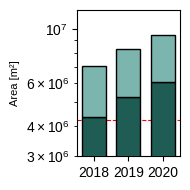

In [29]:
x_df = df[df['year_start'] != '2011 - 2019'].groupby(['year_start'], observed=False).sum().reset_index()
fig, ax = plt.subplots(figsize=(2, 2))
bar1 = sns.barplot(data=x_df, x="year_start", y="area_neg", color=turquoise, label=r'Ablation', width=0.7, ax=ax, edgecolor='black', zorder=3, legend=False)
bar2 = sns.barplot(data=x_df, x="year_start", y="area_pos", bottom=x_df["area_neg"], color=light_turquoise, label=r'Accumulation', width=0.7, ax=ax, edgecolor='black', zorder=3, legend=False)
ax.axhline(df[df['year_start'] == '2011 - 2019']['area_neg'].sum(), color='red', linestyle='--', zorder=0, linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel(r'Area [m²]', fontsize=8)
ax.set_yscale('log')
ax.set_ylim(3e6, 1.2e7)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
plt.tight_layout()
plt.show()

Figure 5d: The distribution of the RTS ablation area from 2019 is the closest to the actual mean ablation area. Due to the lower resolution of DEMs, small RTS cannot be captured compared to the optical RTS inventory. Red dotted and solid lines indicate the mean, minimum / maximum values, respectively, based on DEM-annotated active RTS ablation area.

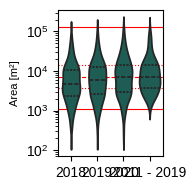

In [30]:
fig, ax = plt.subplots(figsize=(2, 2))
violin = sns.violinplot(data=df, x='year_start', y='area_neg', log_scale=True, color=turquoise, ax=ax, inner='quart')
ax.axhline(df[df['year_start'] == '2011 - 2019']['area_neg'].median(), color='red', linestyle='--', zorder=0, linewidth=0.8)
ax.axhline(df[df['year_start'] == '2011 - 2019']['area_neg'].quantile(0.25), color='red', linestyle='dotted', zorder=0, linewidth=0.8)
ax.axhline(df[df['year_start'] == '2011 - 2019']['area_neg'].quantile(0.75), color='red', linestyle='dotted', zorder=0, linewidth=0.8)
ax.axhline(df[df['year_start'] == '2011 - 2019']['area_neg'].min(), color='red', linestyle='solid', zorder=0, linewidth=0.8)
ax.axhline(df[df['year_start'] == '2011 - 2019']['area_neg'].max(), color='red', linestyle='solid', zorder=0, linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel(r'Area [m²]', fontsize=8)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
plt.tight_layout()
plt.show()

Figure 5e: Material erosion volume: Total material erosion volume calculated based on the RTS ablation area from 2019 shows the best match to actual active ablation area while estimates based on the labels from 2018 under- and from 2020 overestimate the volume change, respectively.

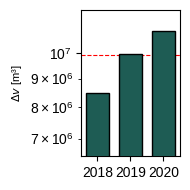

In [33]:
fig, ax = plt.subplots(figsize=(2, 2))
bar = sns.barplot(data=x_df, x="year_start", y="dv_loss", color=turquoise, width=0.7, ax=ax, edgecolor='black', zorder=3, legend=False, errorbar=("pi", 50))
ax.axhline(df[df['year_start'] == '2011 - 2019']['dv_loss'].sum(), color='red', linestyle='--', zorder=0, linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel(r'$\Delta v$ [m³]', fontsize=8) 
ax.set_yscale('log')
ax.set_ylim(6.5e6, 1.2e7)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
plt.tight_layout()
plt.show()

Figure 5f:  TanDEM-X derived elevation compared to UAV-based very high resolution DEMs from field campaign in 2020 for 6 RTS in the Beiluhe region of QTP

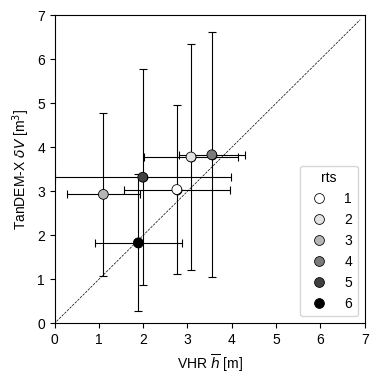

In [34]:
columns=["rts", "total_area", "active_area_perc", "validation_median_height", "validation_median_height_sigma", "tandem_max_height", "tandem_max_height_sigma"]
values = [[1, 7265, 77, 2.76, 1.19, 3.04, 1.91], 
            [2, 9141, 78, 3.08, 1.06, 3.78, 2.57], 
            [3, 2536, 81, 1.10, 0.83,  2.93, 1.85], 
            [4, 9637, 53, 3.55, 0.75, 3.83, 2.78], 
            [5, 3891, 69, 1.99, 1.99, 3.32, 2.46], 
            [6, 1087, 100, 1.89, 0.98, 1.83, 1.56]]
df = pd.DataFrame(columns=columns, data=values, index=[1, 2, 3, 4, 5, 6])

fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(df, x='validation_median_height', y='tandem_max_height', ax=ax, s=50, zorder=2, hue='rts', palette='Greys', edgecolor='black', legend=True)
ax.errorbar(df['validation_median_height'], df['tandem_max_height'], 
            xerr=df['validation_median_height_sigma'], yerr=df['tandem_max_height_sigma'], capsize=3, capthick=0.8, zorder=0, linewidth=0.8, fmt='o',  color='black')
diagonal_line = Line2D([-0.9, 6.9], [-0.9, 6.9], color='black', lw=0.5, linestyle='--')
ax.add_line(diagonal_line)
ax.set_xlim(0,7)
ax.set_ylim(0,7)
ax.set_xlabel(r'VHR $\overline{h}$ [m]', fontsize=10)
ax.set_ylabel(r'TanDEM-X $\delta V$ [m$^3$]', fontsize=10)
plt.show()

Figure 4: RTS mass wasting quantities in QTP subregions

/tmp/ipykernel_3912790/3470364878.py:58: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax10.annotate(f'n={n_samples}', (i, 1.1), textcoords="offset points", verticalalignment='top', ha='center', fontsize=small_font)
/tmp/ipykernel_3912790/3470364878.py:58: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax10.annotate(f'n={n_samples}', (i, 1.1), textcoords="offset points", verticalalignment='top', ha='center', fontsize=small_font)
/tmp/ipykernel_3912790/3470364878.py:58: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax10.annotate(f'n={n_samples}', (i, 1.1), textcoords="offset points", verticalalignment='top', ha='center', fontsize=small_font)
/tmp/ipykernel_3912790/3470364878.py:58: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lea

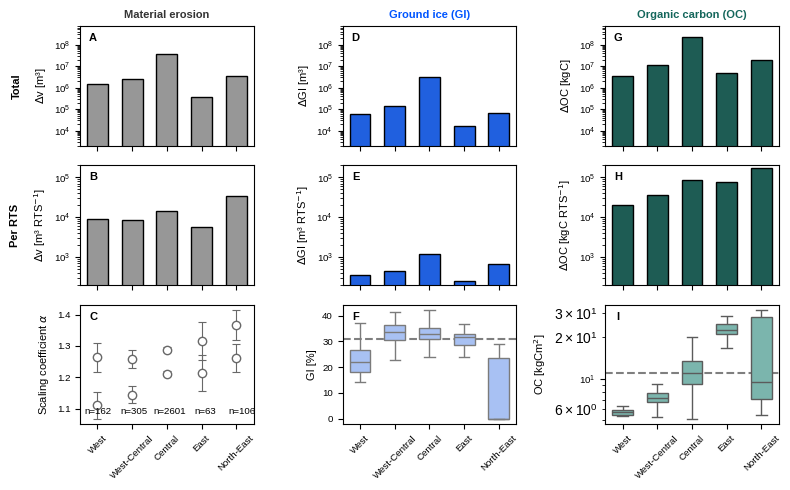

In [55]:
all_labels_cluster = all_labels[all_labels['cluster_name'] != "None"].copy()
all_labels_cluster.loc[all_labels_cluster['data_gi_column'] == 0.0, 'data_gi_column'] = 0.01
all_labels_cluster_rts = all_labels_cluster.copy()

for cluster in median_order:
    count = all_labels_cluster[all_labels_cluster['cluster_name'] == cluster]['gi_data_perc_mean'].count()
    all_labels_cluster_rts.loc[all_labels_cluster_rts['cluster_name'] == cluster, 'dv_loss'] /= count
    all_labels_cluster_rts.loc[all_labels_cluster_rts['cluster_name'] == cluster, 'data_gi_column'] /= count
    all_labels_cluster_rts.loc[all_labels_cluster_rts['cluster_name'] == cluster, 'gi_data_wang_exp_soc_column'] /= count
    all_labels_cluster_rts.loc[all_labels_cluster_rts['cluster_name'] == cluster, 'area_exact'] /= count

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(8, 5), sharex=True)
(ax4, ax5, ax6), (ax7, ax8, ax9), (ax10, ax11, ax12) = axs
normal_font = 8
small_font = 7

sns.barplot(x='cluster_name', y='dv_loss', data=all_labels_cluster, color=greys[2], ax=ax4, zorder=2, errorbar=None, order=median_order, estimator='sum', legend=False, edgecolor='black', width=0.6)
ax4.set_ylabel(r"$\Delta$v [m³]", fontsize=normal_font)
ax4.set_yscale('log')
ax4.set_ylim(2e3, 7e8)
ax4.text(0.075, 0.875, "A", size=normal_font, ha="center", transform=ax4.transAxes, weight='bold')

sns.barplot(x='cluster_name', y='dv_loss', data=all_labels_cluster_rts, color=greys[2], ax=ax7, zorder=2, errorbar=None, order=median_order, estimator='sum', legend=False, edgecolor='black', width=0.6)
ax7.set_ylabel(r"$\Delta$v [m³ RTS$^{-1}$]", fontsize=normal_font)
ax7.set_yscale('log')
ax7.set_ylim(2e2, 2e5)
ax7.text(0.075, 0.875, "B", size=normal_font, ha="center", transform=ax7.transAxes, weight='bold')

plot_df_cluster = all_labels_cluster.copy()
sorted_clusters = sorted(plot_df_cluster['cluster_name'].unique(), key=lambda x: ["West", "West-Central", "Central", "East", "North-East", "Individual"].index(x))
alphas = pd.DataFrame(columns=['cluster_name', 'alpha', 'alpha_std'])
for idx, cluster in enumerate(sorted_clusters):
	data = plot_df_cluster[(plot_df_cluster['cluster_name'] == cluster)]    
	area_log = np.log10(np.nan_to_num(data['area_neg']))
	volume_log = np.log10(np.nan_to_num(data['dv_loss']))
	p, R, RMSE, p_val, t, s_err, n, stds, t2 = allometric_scaling.perform_fit(area_log, volume_log, model='OLS')
	alphas.loc[idx] = [cluster, p[0], stds[0]]

alphas2 = pd.DataFrame(columns=['cluster_name', 'alpha', 'alpha_std'])
for idx, cluster in enumerate(sorted_clusters):
	data = plot_df_cluster[(plot_df_cluster['cluster_name'] == cluster)]    
	area_log = np.log10(np.nan_to_num(data['area_neg']))
	volume_log = np.log10(np.nan_to_num(data['dv_loss']))
	p, R, RMSE, p_val, t, s_err, n, stds, t2 = allometric_scaling.perform_fit(area_log, volume_log, model='ODR')
	alphas2.loc[idx] = [cluster, p[0], stds[0]]


ax10.errorbar(x=alphas['cluster_name'], y=alphas['alpha'], yerr=alphas['alpha_std'], fmt='o', markerfacecolor='white', markeredgecolor=greys[1], color=greys[1], capsize=3, capthick=0.8, zorder=2, linewidth=0.8)
ax10.errorbar(x=alphas2['cluster_name'], y=alphas2['alpha'], yerr=alphas2['alpha_std'], fmt='o', markerfacecolor='white', markeredgecolor=greys[1], color=greys[1], capsize=3, capthick=0.8, zorder=2, linewidth=0.8)

ax10.set_ylabel(r'Scaling coefficient $\alpha$', fontsize=normal_font)
ax10.set_xlabel('')
ax10.set_xticks(range(5))
ax10.set_xticklabels(labels=median_order, rotation=45)
ax10.text(0.075, 0.875, "C", size=normal_font, ha="center", transform=ax10.transAxes, weight='bold')
for i, cluster in enumerate(alphas['cluster_name']):
	n_samples = len(all_labels_cluster_rts[(all_labels_cluster_rts['cluster_name'] == cluster)]) 
	ax10.annotate(f'n={n_samples}', (i, 1.1), textcoords="offset points", verticalalignment='top', ha='center', fontsize=small_font)

sns.barplot(x='cluster_name', y='data_gi_column', data=all_labels_cluster, color=blue, ax=ax5, zorder=2, errorbar=None, order=median_order, estimator='sum', legend=False, edgecolor='black', width=0.6)
ax5.set_ylabel(r'$\Delta$GI [m³]', fontsize=normal_font)
ax5.set_yscale('log')
ax5.set_ylim(2e3, 7e8)
ax5.text(0.075, 0.875, "D", size=normal_font, ha="center", transform=ax5.transAxes, weight='bold')

sns.barplot(x='cluster_name', y='data_gi_column', data=all_labels_cluster_rts, color=blue, ax=ax8, zorder=2, errorbar=None,order=median_order, estimator='sum', legend=False, edgecolor='black', width=0.6)    
ax8.set_ylabel(r'$\Delta$GI [m³ RTS$^{-1}$]', fontsize=normal_font)
ax8.set_yscale('log')
ax8.set_ylim(2e2, 2e5)
ax8.text(0.075, 0.875, "E", size=normal_font, ha="center", transform=ax8.transAxes, weight='bold')

sns.boxplot(x='cluster_name', y='gi_data_perc_mean', data=all_labels_cluster, color=light_blue, ax=ax11, order=median_order, zorder=2, width=0.6, showfliers=False)
ax11.axhline(y=all_labels_cluster['gi_data_perc_mean'].mean(), color='black', linestyle='--', alpha=0.5, zorder=1)
ax11.set_ylabel('GI [%]', fontsize=normal_font)
ax11.set_xticks(range(5))
ax11.set_xticklabels(labels=median_order, rotation=45)
ax11.set_xlabel('')
ax11.text(0.075, 0.875, "F", size=normal_font, ha="center", transform=ax11.transAxes, weight='bold')

sns.barplot(x='cluster_name', y='gi_data_wang_exp_soc_column', data=all_labels_cluster, color=turquoise, ax=ax6, zorder=2, errorbar=None, order=median_order, estimator='sum', legend=False, edgecolor='black', width=0.6)
ax6.set_ylabel(r'$\Delta$OC [kgC]', fontsize=normal_font)
ax6.set_yscale('log')
ax6.set_ylim(2e3, 7e8)
ax6.text(0.075, 0.875, "G", size=normal_font, ha="center", transform=ax6.transAxes, weight='bold')

sns.barplot(x='cluster_name', y='gi_data_wang_exp_soc_column', data=all_labels_cluster_rts, color=turquoise, ax=ax9, zorder=2, errorbar=None, order=median_order, estimator='sum', legend=False, edgecolor='black', width=0.6)    
ax9.set_ylabel(r'$\Delta$OC [kgC RTS$^{-1}$]', fontsize=normal_font)
ax9.set_yscale('log')
ax9.set_ylim(2e2, 2e5)
ax9.text(0.075, 0.875, "H", size=normal_font, ha="center", transform=ax9.transAxes, weight='bold')

sns.boxplot(x='cluster_name', y='wang_soc_column_content', data=all_labels_cluster, color=light_turquoise, ax=ax12, order=median_order, zorder=2, width=0.6, showfliers=False)
ax12.set_ylabel(r'OC [kgCm$^2$]', fontsize=normal_font)
ax12.axhline(y=all_labels_cluster['wang_soc_column_content'].mean(), color='black', linestyle='--', alpha=0.5, zorder=1)
ax12.set_yscale('log')
ax12.set_xticks(range(5))
ax12.set_xticklabels(labels=median_order, rotation=45)
ax12.set_xlabel('')
ax12.text(0.075, 0.875, "I", size=normal_font, ha="center", transform=ax12.transAxes, weight='bold')

rect1 = patches.Rectangle((0, 0.75), 1, 0.25, transform=fig.transFigure, color=greys[4], zorder=-1)

for ax, col, color in zip(axs[0], ['Material erosion', 'Ground ice (GI)', 'Organic carbon (OC)'], [greys[0], blue, turquoise]):
	ax.set_title(col, fontsize=normal_font, weight='bold', color=color)

for ax, row in zip(axs[:, 0], ['Total', 'Per RTS', '']):
	ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
				xycoords=ax.yaxis.label, textcoords='offset points',
				ha='right', va='center', fontsize=normal_font, rotation=90, weight='bold')

for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=small_font)
	
plt.tight_layout()
plt.show()   

Supplement: Figure S1 Allometric scaling between the actively eroding area of the delineations of the RTS inventory dA and the computed volume change based on the negative elevation change of the TanDEM-X DEM (T1 - T2) computed with OLS (in purple) and with ODR (in black).

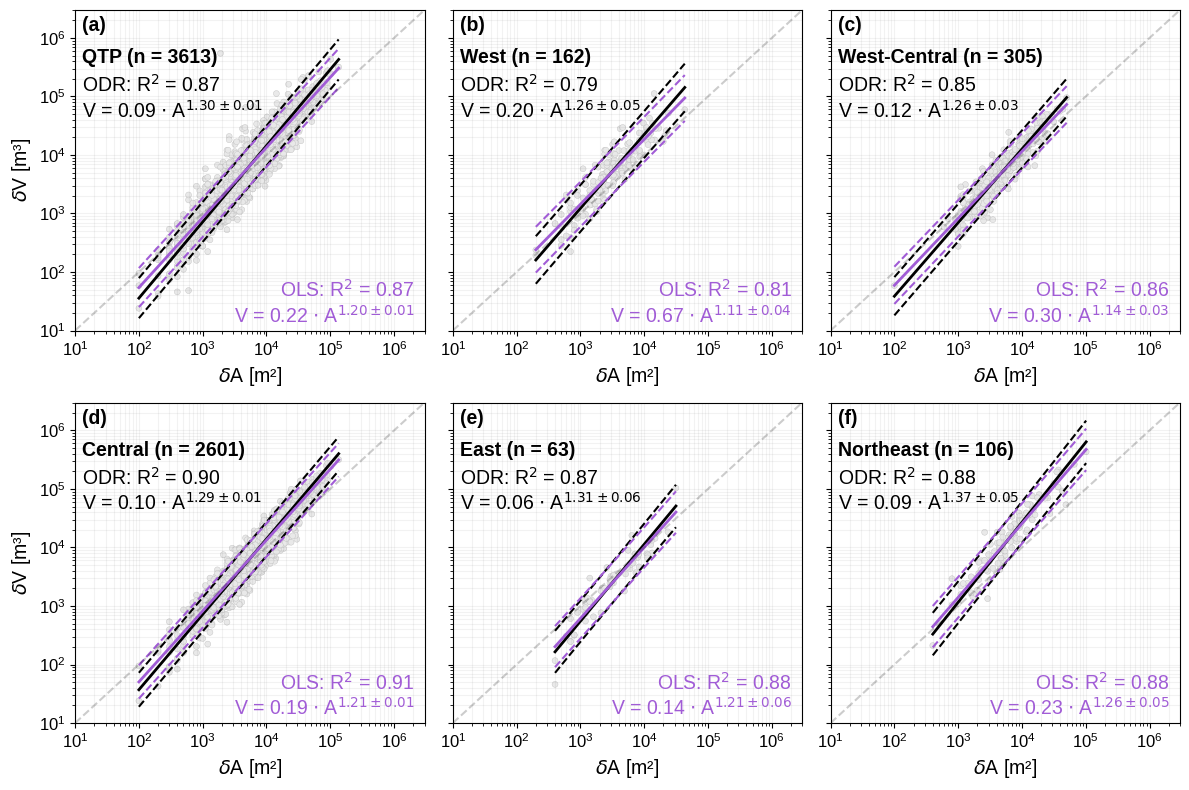

In [59]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharex=False, sharey=True)
plot_df_cluster = all_labels.copy()
sorted_clusters = sorted(plot_df_cluster['cluster_name'].unique(), key=lambda x: ["Individual", "West", "West-Central", "Central", "East", "North-East"].index(x))

label_list = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
for idx, cluster in enumerate(sorted_clusters):
    if cluster == "Individual":
        cluster = "QTP"
        data = plot_df_cluster
    else:
        data = plot_df_cluster[(plot_df_cluster['cluster_name'] == cluster)]   

    ax = axs.flatten()[idx]

    # ODR scaling
    area_log = np.log10(np.nan_to_num(data['area_neg']))
    volume_log = np.log10(np.nan_to_num(data['dv_loss']))
    p, R, RMSE, p_val, t, s_err, n, stds, t2 = allometric_scaling.perform_fit(area_log, volume_log, model='ODR')
    y_model = allometric_scaling.powerlaw(area_log, *p)
    x2 = np.linspace(np.min(area_log), np.max(area_log), 100)
    y2 = allometric_scaling.powerlaw(x2, *p)
    pi = t * s_err * np.sqrt(1 + 1/n + (x2 - np.mean(area_log))**2 / np.sum((area_log - np.mean(area_log))**2)) 

    sns.scatterplot(data=data,  x='area_neg', y='dv_loss', color=greys[4], ax=ax, edgecolor=greys[3], alpha=1.0, legend=False, size=0.5) 
    sns.lineplot(x= 10**(area_log), y=10**(y_model), linestyle="-", color='black', linewidth=2, alpha=1, ax=ax)  
    sns.lineplot(x=10**(x2), y=10**(y2 - pi), linestyle="--", color='black', ax=ax)
    sns.lineplot(x=10**(x2), y=10**(y2 + pi), linestyle="--", color='black', ax=ax)

    # OLS scaling
    p_ols, R_ols, RMSE_ols, p_val_ols, t_ols, s_err_ols, n_ols, stds_ols, t2_ols = allometric_scaling.perform_fit(area_log, volume_log, model='OLS')
    y_model_ols = allometric_scaling.powerlaw(area_log, *p_ols)
    x2_ols = np.linspace(np.min(area_log), np.max(area_log), 100)
    y2_ols = allometric_scaling.powerlaw(x2_ols, *p_ols)
    pi_ols = t_ols * s_err_ols * np.sqrt(1 + 1/n_ols + (x2_ols - np.mean(area_log))**2 / np.sum((area_log - np.mean(area_log))**2)) 

    sns.lineplot(x= 10**(area_log), y=10**(y_model_ols), linestyle="-", color="#a15cd6ff", linewidth=2, alpha=1, ax=ax)  
    sns.lineplot(x=10**(x2_ols), y=10**(y2_ols - pi_ols), linestyle="--", color="#a15cd6ff", ax=ax)
    sns.lineplot(x=10**(x2), y=10**(y2_ols + pi_ols), linestyle="--", color="#a15cd6ff", ax=ax)


    ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='black', linestyle='--', alpha=0.2)
    ax.text(0.02, 0.98, f"{label_list[idx]}", transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left', weight='bold')
    if cluster == "North-East":
        cluster = "Northeast"
    ax.text(0.02, 0.88, f"{cluster} (n = {n})", transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left', weight='bold')

    ax.text(0.02, 0.72, r'V = {:.2f} $\cdot$ A$^{{{:.2f} \pm {:.2f}}}$'.format(10**p[1], p[0], stds[0]), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left')
    ax.text(0.02, 0.8, r'ODR: R$^2$ = {:.2f}'.format(R), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left')

    ax.text(0.97, 0.08, r'V = {:.2f} $\cdot$ A$^{{{:.2f} \pm {:.2f}}}$'.format(10**p_ols[1], p_ols[0], stds_ols[0]), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='right', color="#a15cd6ff")
    ax.text(0.97, 0.16, r'OLS: R$^2$ = {:.2f}'.format(R_ols), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='right', color="#a15cd6ff")
    
    
    ax.set_xlabel(r'$\delta$A [m²]', fontsize=14)
    ax.set_ylabel(r'$\delta$V [m³]', fontsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True,which="both",ls="-",c='gray', alpha=0.1)  
    ax.set_xlim(1e1, 3e6)
    ax.set_ylim(1e1, 3e6)
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

Supplement: Figure S3 Allometric scaling between the entire area of the delineated scar zone AXia of the RTS inventory and the computed volume change based on the elevation change of the TanDEM-X DEMs within the ablation area computed with OLS (in purple) and with ODR (in black). 

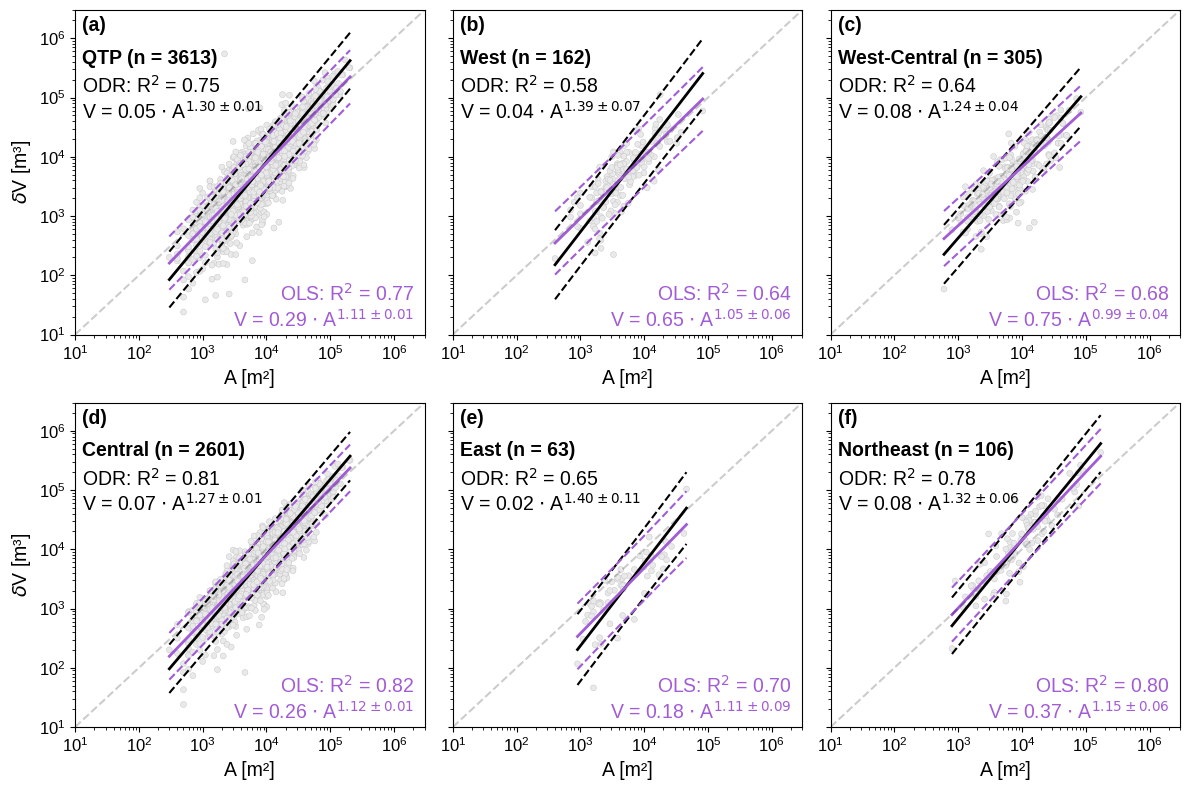

In [61]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharex=False, sharey=True)
plot_df_cluster = all_labels.copy()
sorted_clusters = sorted(plot_df_cluster['cluster_name'].unique(), key=lambda x: ["Individual", "West", "West-Central", "Central", "East", "North-East"].index(x))

label_list = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
for idx, cluster in enumerate(sorted_clusters):
    if cluster == "Individual":
        cluster = "QTP"
        data = plot_df_cluster
    else:
        data = plot_df_cluster[(plot_df_cluster['cluster_name'] == cluster)]   
    ax = axs.flatten()[idx]

    area_log = np.log10(np.nan_to_num(data['area']))
    volume_log = np.log10(np.nan_to_num(data['dv_loss']))
    p, R, RMSE, p_val, t, s_err, n, stds, t2 = allometric_scaling.perform_fit(area_log, volume_log, model='ODR')
    y_model = allometric_scaling.powerlaw(area_log, *p)
    x2 = np.linspace(np.min(area_log), np.max(area_log), 100)
    y2 = allometric_scaling.powerlaw(x2, *p)
    pi = t * s_err * np.sqrt(1 + 1/n + (x2 - np.mean(area_log))**2 / np.sum((area_log - np.mean(area_log))**2)) 

    sns.scatterplot(data=data,  x='area', y='dv_loss', color=greys[4], ax=ax, edgecolor=greys[3], alpha=1.0, legend=False, size=0.5) 
    sns.lineplot(x= 10**(area_log), y=10**(y_model), linestyle="-", color='black', linewidth=2, alpha=1, ax=ax)  
    sns.lineplot(x=10**(x2), y=10**(y2 - pi), linestyle="--", color='black', ax=ax)
    sns.lineplot(x=10**(x2), y=10**(y2 + pi), linestyle="--", color='black', ax=ax)

    p_ols, R_ols, RMSE_ols, p_val_ols, t_ols, s_err_ols, n_ols, stds_ols, t2_ols = allometric_scaling.perform_fit(area_log, volume_log, model='OLS')
    y_model_ols = allometric_scaling.powerlaw(area_log, *p_ols)
    x2_ols = np.linspace(np.min(area_log), np.max(area_log), 100)
    y2_ols = allometric_scaling.powerlaw(x2_ols, *p_ols)
    pi_ols = t_ols * s_err_ols * np.sqrt(1 + 1/n_ols + (x2_ols - np.mean(area_log))**2 / np.sum((area_log - np.mean(area_log))**2)) 

    sns.lineplot(x= 10**(area_log), y=10**(y_model_ols), linestyle="-", color="#a15cd6ff", linewidth=2, alpha=1, ax=ax)  
    sns.lineplot(x=10**(x2_ols), y=10**(y2_ols - pi_ols), linestyle="--", color="#a15cd6ff", ax=ax)
    sns.lineplot(x=10**(x2), y=10**(y2_ols + pi_ols), linestyle="--", color="#a15cd6ff", ax=ax)



    ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='black', linestyle='--', alpha=0.2)
    ax.text(0.02, 0.98, f"{label_list[idx]}", transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left', weight='bold')
    if cluster == "North-East":
        cluster = "Northeast"
    ax.text(0.02, 0.88, f"{cluster} (n = {n})", transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left', weight='bold')

    ax.text(0.02, 0.72, r'V = {:.2f} $\cdot$ A$^{{{:.2f} \pm {:.2f}}}$'.format(10**p[1], p[0], stds[0]), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left')
    ax.text(0.02, 0.8, r'ODR: R$^2$ = {:.2f}'.format(R), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='left')

    ax.text(0.97, 0.08, r'V = {:.2f} $\cdot$ A$^{{{:.2f} \pm {:.2f}}}$'.format(10**p_ols[1], p_ols[0], stds_ols[0]), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='right', color="#a15cd6ff")
    ax.text(0.97, 0.16, r'OLS: R$^2$ = {:.2f}'.format(R_ols), transform=ax.transAxes, fontsize=14, verticalalignment='top', ha='right', color="#a15cd6ff")

    ax.set_xlabel(r'A [m²]', fontsize=14)
    ax.set_ylabel(r'$\delta$V [m³]', fontsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlim(1e1, 3e6)
    ax.set_ylim(1e1, 3e6)
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()